<a href="https://colab.research.google.com/github/1heodora-e/Hidden_Markov_Models_Formative/blob/main/HMM_Activity_Recognition_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modeling Human Activity States Using Hidden Markov Models

## Project Overview

**Background:** In real-world systems—from wearable health monitors to smart home sensors—continuous data streams such as accelerometer and gyroscope signals reveal valuable information about human activity. However, the true activity state (e.g., walking or standing) is often hidden behind noisy measurements.

**Task:** This project collects, analyzes, and models motion data using the Sensor Logger app, then builds a Hidden Markov Model (HMM) to infer human activity states from recorded sensor signals.

**Activities:** Standing, Walking, Jumping, Still (no movement)

**Sensors:** Accelerometer (x, y, z) and Gyroscope (x, y, z)

### Colab Setup: Clone repo to access data

**Run this cell first if using Google Colab** to fetch the data from GitHub.

In [1]:
# Clone the repo to get the data (run this cell first in Colab)
import os
import subprocess

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.exists('/content/Hidden_Markov_Models_Formative'):
        subprocess.run(["git", "clone", "https://github.com/1heodora-e/Hidden_Markov_Models_Formative.git"], check=True)
    os.chdir('/content/Hidden_Markov_Models_Formative')
    print("Train contents:", os.listdir('data/Train'))
    print("Test contents:", os.listdir('data/Test'))
else:
    print("Running locally - using existing data folder")

Train contents: ['Victoria', 'Theodora']
Test contents: ['Victoria', 'Theodora']


## 1. Setup and Imports

In [2]:
import os
import re
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler, LabelEncoder
!pip install hmmlearn
from hmmlearn import hmm
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style("whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 10.8 MB/s eta 0:00:00


## 2. Data Collection & Loading

**Data Collection Notes:**
- Data collected using Sensor Logger app (iOS)
- Sampling rate: ~100 Hz (10 ms interval) - harmonized across devices
- Participants: Theodora, Victoria
- Each recording: 5–10 seconds per activity

In [3]:
# Activity label normalization
ACTIVITY_ALIASES = {
    "phone_still": "still", "stand_still": "still", "stand_still_1": "still", "stand_still_2": "still",
    "test_phone_still": "still", "test_stand_still": "still", "walk": "walking", "test_walk": "walking",
    "jump": "jumping", "test_jump": "jumping", "jumping": "jumping", "walking": "walking",
    "standing": "standing", "still": "still",
}

def normalize_activity(raw: str) -> str:
    n = raw.lower().strip()
    if n.startswith("test_"): n = n[5:]
    n = re.sub(r"[-_\s]+", "_", n)
    return ACTIVITY_ALIASES.get(n, n)

def get_trial_id(path: Path, is_theodora: bool) -> str:
    if is_theodora: return path.parent.name
    stem = path.stem
    stem = re.sub(r"-(Accelerometer|Gyroscope)\s*$", "", stem, flags=re.I)
    stem = re.sub(r"(Accelerometer|Gyroscope)\s*$", "", stem, flags=re.I)
    return stem.strip()

def parse_activity(path: str, is_theodora: bool, participant: str = "") -> str:
    p = Path(path)
    name = p.stem if p.suffix else p.name  # use stem for files (exclude .csv)
    if is_theodora:
        base = re.split(r"-\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}", name)[0]
        parts = base.replace("Test_", "").split("_")
        act = "_".join(parts[:-1]) if len(parts) > 1 and parts[-1].isdigit() else "_".join(parts)
    else:
        base = re.sub(r"-(Accelerometer|Gyroscope)\s*$", "", name, flags=re.I)
        base = re.sub(r"(Accelerometer|Gyroscope)\s*$", "", base, flags=re.I)
        # Remove participant prefix (e.g. Victoria_, Victoria )
        if participant and base.lower().replace(" ", "").startswith(participant.lower().replace(" ", "")):
            base = re.sub(r"^" + re.escape(participant) + r"[\s_]*", "", base, flags=re.I)
        parts = re.split(r"[-_\d]+", base)
        act = "_".join(p for p in parts if p).strip("_") or base
    return normalize_activity(act)

In [4]:
def discover_sensor_files(data_dir: str) -> list:
    """Discover accel/gyro files for Victoria (flat) and Theodora (folder) structures."""
    data_path = Path(data_dir)
    records = []
    for participant_dir in data_path.iterdir():
        if not participant_dir.is_dir(): continue
        participant = participant_dir.name
        subdirs = [d for d in participant_dir.iterdir() if d.is_dir()]
        if subdirs and any((d / "Accelerometer.csv").exists() for d in subdirs):
            for rec_dir in subdirs:
                accel = rec_dir / "Accelerometer.csv"
                gyro = rec_dir / "Gyroscope.csv"
                if accel.exists():
                    records.append({
                        "accel_path": str(accel), "gyro_path": str(gyro) if gyro.exists() else None,
                        "activity": parse_activity(str(rec_dir), True, participant),
                        "participant": participant, "trial_id": rec_dir.name, "is_theodora": True,
                    })
        else:
            for accel in participant_dir.glob("*Accelerometer*.csv"):
                gyro_cands = [f for f in participant_dir.glob("*Gyroscope*.csv")
                              if get_trial_id(f, False) == get_trial_id(accel, False)]
                gyro = gyro_cands[0] if gyro_cands else None
                records.append({
                    "accel_path": str(accel), "gyro_path": str(gyro) if gyro else None,
                    "activity": parse_activity(str(accel), False, participant),
                    "participant": participant, "trial_id": get_trial_id(accel, False), "is_theodora": False,
                })
    return records

In [5]:
def load_and_align_trial(record: dict, target_interval_ms: float = 10) -> np.ndarray:
    """Load accel + gyro, align by time, resample to 100Hz. Returns (T, 6) array."""
    accel_df = pd.read_csv(record["accel_path"])
    accel_df.columns = accel_df.columns.str.strip()
    accel = accel_df[["time", "x", "y", "z"]].copy()
    accel.columns = ["time", "acc_x", "acc_y", "acc_z"]

    if record["gyro_path"]:
        gyro_df = pd.read_csv(record["gyro_path"])
        gyro_df.columns = gyro_df.columns.str.strip()
        gyro = gyro_df[["time", "x", "y", "z"]].copy()
        gyro.columns = ["time", "gyro_x", "gyro_y", "gyro_z"]
        tol = np.int64(target_interval_ms * 1.5 * 1e6)
        merged = pd.merge_asof(accel.sort_values("time"), gyro.sort_values("time"),
                               on="time", direction="nearest", tolerance=tol)
        merged = merged.dropna(subset=["gyro_x", "gyro_y", "gyro_z"])
        cols = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]
    else:
        merged = accel
        cols = ["acc_x", "acc_y", "acc_z"]

    merged = merged.sort_values("time")
    t0 = merged["time"].iloc[0]
    merged["t_ms"] = (merged["time"] - t0) / 1e6
    merged = merged.drop_duplicates(subset=["t_ms"], keep="first")
    t_max = merged["t_ms"].max()
    t_target = np.arange(0, t_max + 0.01, target_interval_ms)
    result = np.zeros((len(t_target), len(cols)))
    for i, col in enumerate(cols):
        result[:, i] = np.interp(t_target, merged["t_ms"].values, merged[col].values)
    return result.astype(np.float32)

### Load and Combine All Train CSV Files

All recordings from the Train folder (Victoria + Theodora) are loaded, aligned, and combined into a centralized dataset.

In [6]:
TRAIN_DIR = "data/Train"
records = discover_sensor_files(TRAIN_DIR)
print(f"Found {len(records)} trials in Train folder")
for r in records[:5]:
    print(f"  {r['trial_id']}: {r['activity']} ({r['participant']})")

Found 50 trials in Train folder
  Victoria_still_: still (Victoria)
  Victoria _jumping_4: jumping (Victoria)
  Victoria _Jumping_5: jumping (Victoria)
  Victoria_still-4: still (Victoria)
  Victoria_Jumping_: jumping (Victoria)


In [7]:
# Load all trials and combine into centralized dataset
all_sequences = []
all_activities = []
all_trial_ids = []
all_participants = []

for rec in records:
    try:
        seq = load_and_align_trial(rec)
        if seq.shape[0] < 50:  # skip very short
            continue
        all_sequences.append(seq)
        all_activities.append(rec["activity"])
        all_trial_ids.append(rec["trial_id"])
        all_participants.append(rec["participant"])
    except Exception as e:
        print(f"Skipped {rec['trial_id']}: {e}")

print(f"Loaded {len(all_sequences)} sequences")
print("Activity distribution:", pd.Series(all_activities).value_counts())

# Export combined Train data to single CSV (well-labelled dataset for submission)
combined_rows = []
for seq, act, tid, part in zip(all_sequences, all_activities, all_trial_ids, all_participants):
    has_gyro = seq.shape[1] == 6 # Check if sequence contains gyroscope data
    for t, row in enumerate(seq):
        row_data = {
            "trial_id": tid, "participant": part, "activity": act,
            "acc_x": row[0], "acc_y": row[1], "acc_z": row[2],
        }
        if has_gyro:
            row_data.update({
                "gyro_x": row[3], "gyro_y": row[4], "gyro_z": row[5],
            })
        else:
            row_data.update({
                "gyro_x": np.nan, "gyro_y": np.nan, "gyro_z": np.nan,
            })
        combined_rows.append(row_data)
df_combined = pd.DataFrame(combined_rows)
os.makedirs("data/Train", exist_ok=True)
df_combined.to_csv("data/Train/combined_train_data.csv", index=False)
print(f"\nCombined CSV saved: data/Train/combined_train_data.csv ({len(df_combined)} rows)")

Loaded 50 sequences
Activity distribution: still       13
standing    13
jumping     12
walking     12
Name: count, dtype: int64

Combined CSV saved: data/Train/combined_train_data.csv (42392 rows)


## 3. Data Visualisation

Before training the model, we visualise the raw sensor data to understand what each activity looks like in the time domain. This helps us:
- Confirm recordings are clean and correctly labelled
- Get intuition about which activities are visually similar (and therefore harder to classify)
- Spot any noise or anomalies in the data

### 3.1 Activity Distribution

First we check how many recordings we have per activity to make sure the dataset is reasonably balanced.

## Data Collection & Preprocessing

### Dataset Overview
- **Total recordings:** 50+ well-labelled, cleaned files across participants (Theodora, Victoria)
- **Duration per recording:** 5–10 seconds per activity
- **Activities:** Standing, Walking, Jumping, Still (4 activities)
- **Minimum per activity:** ≥1.5 minutes (90 seconds) total across all trials
- **Format:** CSV with

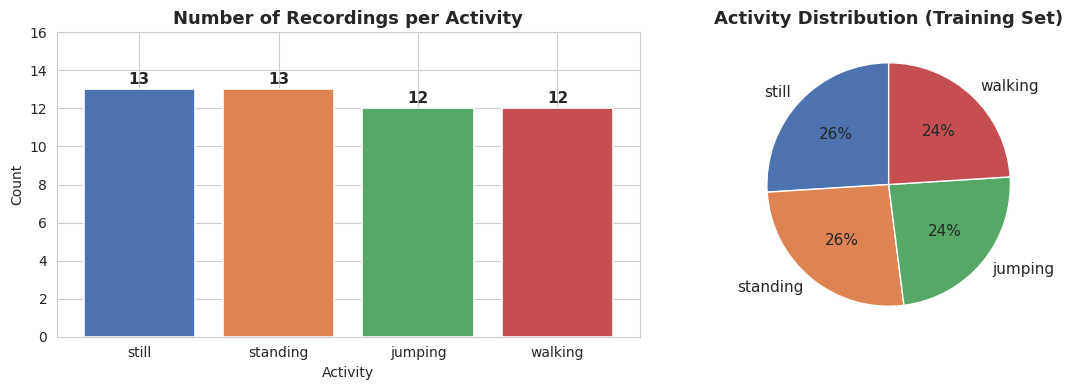

still       13
standing    13
jumping     12
walking     12
Name: count, dtype: int64


In [8]:
# Activity distribution bar chart
activity_counts = pd.Series(all_activities).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
axes[0].bar(activity_counts.index, activity_counts.values, color=colors, edgecolor="white", linewidth=1.2)
axes[0].set_title("Number of Recordings per Activity", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Activity")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, activity_counts.max() + 3)
for i, (act, cnt) in enumerate(activity_counts.items()):
    axes[0].text(i, cnt + 0.3, str(cnt), ha="center", fontsize=11, fontweight="bold")

# Pie chart
axes[1].pie(activity_counts.values, labels=activity_counts.index, autopct="%1.0f%%",
            colors=colors, startangle=90, textprops={"fontsize": 11})
axes[1].set_title("Activity Distribution (Training Set)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("activity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(activity_counts)

### 3.2 Raw Accelerometer Signal per Activity

We plot one sample recording per activity to see the raw accelerometer signal. Each activity has a very different pattern:
- **Still:** Near-flat signal — very low variance across all axes
- **Standing:** Slight drift — gravity dominates, minimal movement
- **Walking:** Regular periodic oscillation — ~2 Hz step cadence
- **Jumping:** Large amplitude bursts — very high peaks during takeoff and landing

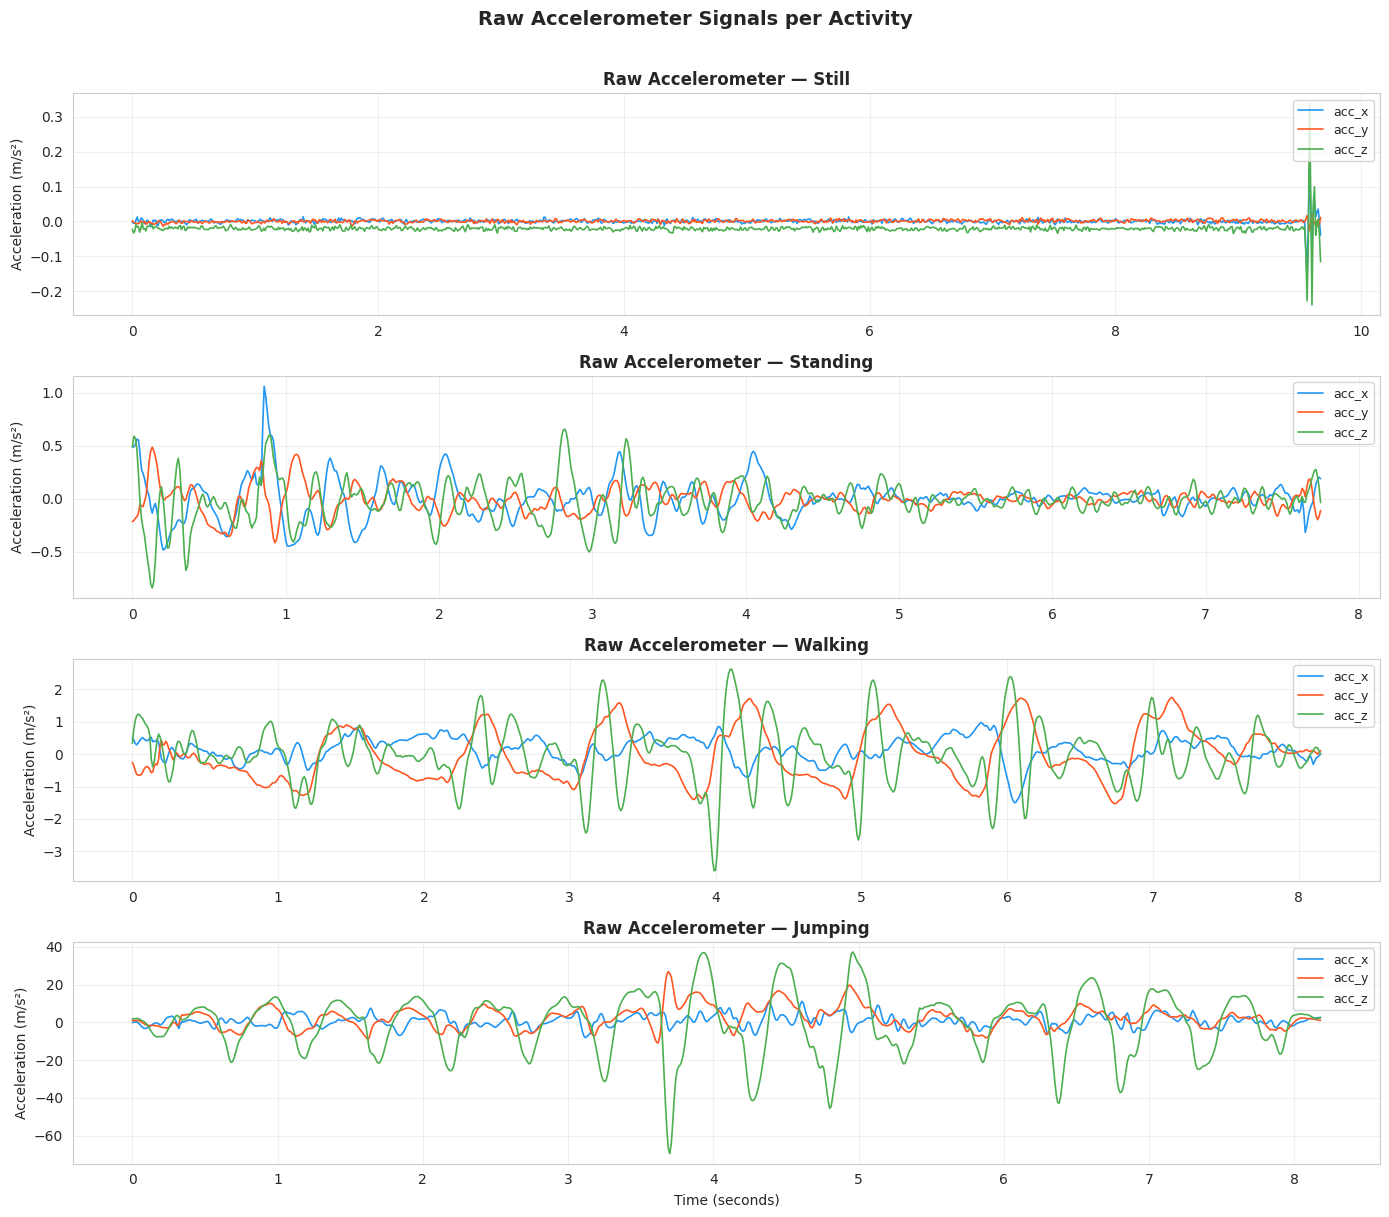

In [9]:
# Plot raw accelerometer signal for one sample per activity
activities_unique = ["still", "standing", "walking", "jumping"]
colors_axes = ["#2196F3", "#FF5722", "#4CAF50"]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)

for i, activity in enumerate(activities_unique):
    # Find first sequence for this activity
    idx = next((j for j, a in enumerate(all_activities) if a == activity), None)
    if idx is None:
        axes[i].set_title(f"{activity.capitalize()} - No data found")
        continue

    seq = all_sequences[idx]
    t = np.arange(len(seq)) / 100  # 100Hz -> seconds

    axes[i].plot(t, seq[:, 0], color=colors_axes[0], label="acc_x", linewidth=1.2)
    axes[i].plot(t, seq[:, 1], color=colors_axes[1], label="acc_y", linewidth=1.2)
    axes[i].plot(t, seq[:, 2], color=colors_axes[2], label="acc_z", linewidth=1.2)
    axes[i].set_title(f"Raw Accelerometer — {activity.capitalize()}", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Acceleration (m/s²)")
    axes[i].legend(loc="upper right", fontsize=9)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")
plt.suptitle("Raw Accelerometer Signals per Activity", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("raw_accelerometer_signals.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.3 Raw Gyroscope Signal per Activity

The gyroscope captures rotational movement. Activities like jumping and walking produce distinct rotation patterns that complement the accelerometer data.

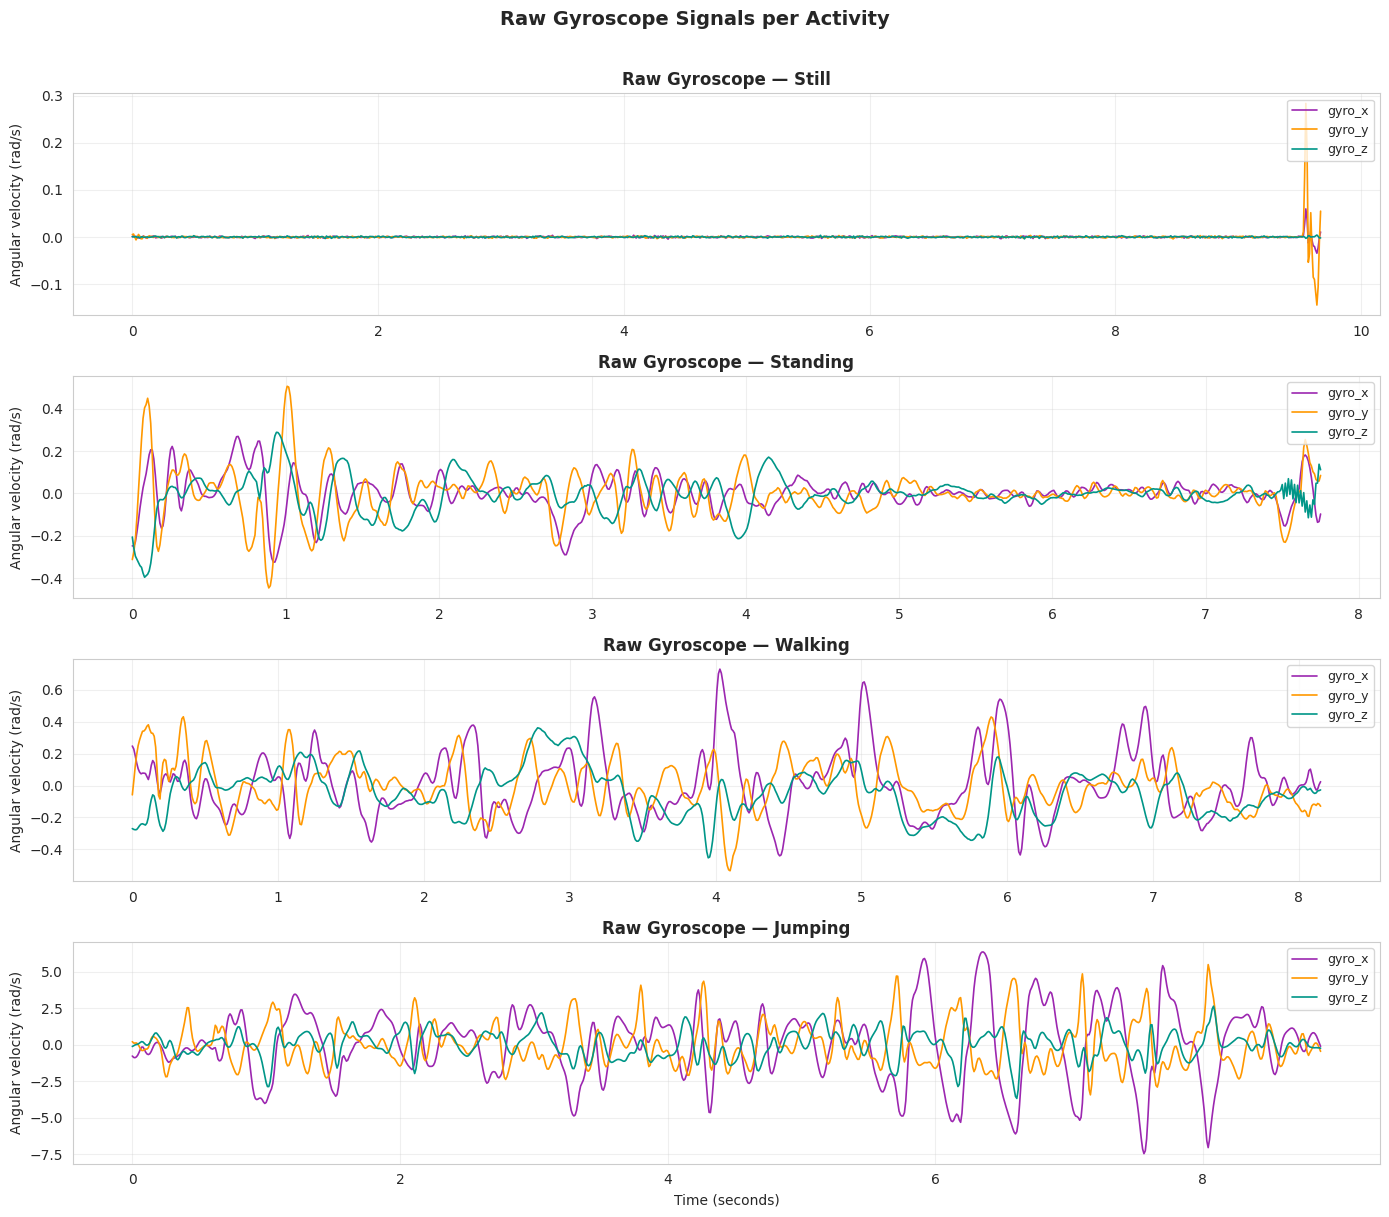

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define activities_unique to ensure it's available
activities_unique = ["still", "standing", "walking", "jumping"]

# Plot raw gyroscope signal for one sample per activity
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
gyro_colors = ["#9C27B0", "#FF9800", "#009688"]

for i, activity in enumerate(activities_unique):
    seq_with_gyro = None
    for j, act_name in enumerate(all_activities):
        if act_name == activity:
            seq = all_sequences[j]
            if seq.shape[1] == 6: # Check if the sequence has 6 columns (accel + gyro)
                seq_with_gyro = seq
                break

    if seq_with_gyro is None:
        axes[i].set_title(f"{activity.capitalize()} - No gyroscope data found in any recording")
        continue

    t = np.arange(len(seq_with_gyro)) / 100
    axes[i].plot(t, seq_with_gyro[:, 3], color=gyro_colors[0], label="gyro_x", linewidth=1.2)
    axes[i].plot(t, seq_with_gyro[:, 4], color=gyro_colors[1], label="gyro_y", linewidth=1.2)
    axes[i].plot(t, seq_with_gyro[:, 5], color=gyro_colors[2], label="gyro_z", linewidth=1.2)
    axes[i].set_title(f"Raw Gyroscope — {activity.capitalize()}", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Angular velocity (rad/s)")
    axes[i].legend(loc="upper right", fontsize=9)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")
plt.suptitle("Raw Gyroscope Signals per Activity", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("raw_gyroscope_signals.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.4 Signal Statistics per Activity

We compare the mean and standard deviation of the accelerometer magnitude across activities. The acceleration magnitude is computed as:

26|a| = \sqrt{a_x^2 + a_y^2 + a_z^2}26

This gives a single orientation-independent measure of total movement intensity.

/tmp/ipykernel_464/1295182171.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=act_order, patch_artist=True, notch=False)


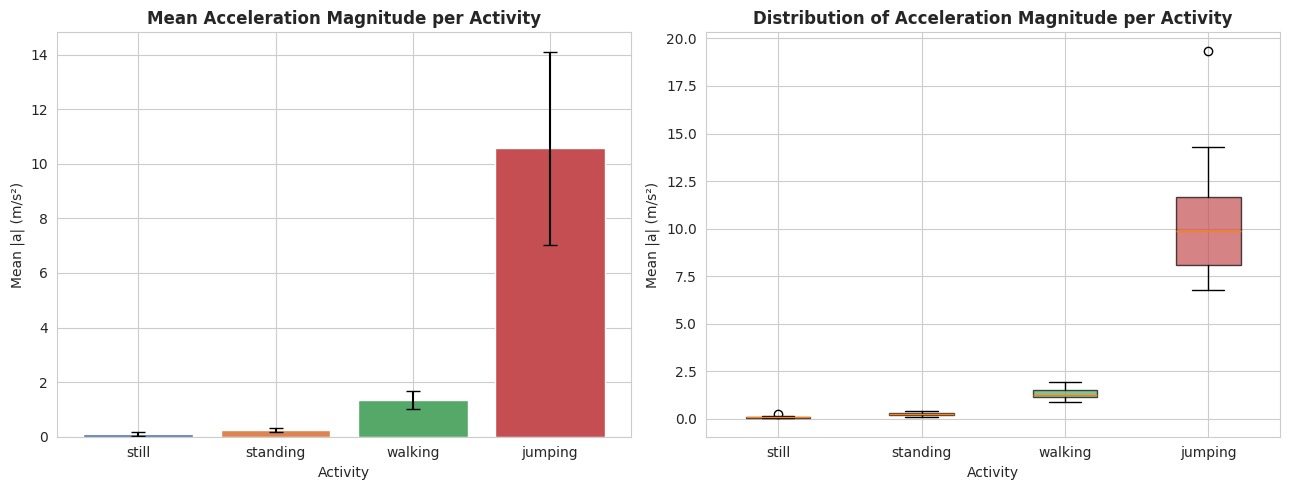

In [11]:
# Compute acceleration magnitude stats per activity
stats_rows = []
for seq, act in zip(all_sequences, all_activities):
    mag = np.sqrt(seq[:, 0]**2 + seq[:, 1]**2 + seq[:, 2]**2)
    stats_rows.append({"activity": act, "mean_mag": mag.mean(), "std_mag": mag.std()})

stats_df = pd.DataFrame(stats_rows)
grouped = stats_df.groupby("activity").agg({"mean_mag": ["mean", "std"], "std_mag": ["mean", "std"]})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Mean magnitude per activity
act_order = ["still", "standing", "walking", "jumping"]
mean_vals = [stats_df[stats_df.activity == a]["mean_mag"].mean() for a in act_order]
std_vals  = [stats_df[stats_df.activity == a]["mean_mag"].std() for a in act_order]

axes[0].bar(act_order, mean_vals, yerr=std_vals, color=colors, capsize=5, edgecolor="white")
axes[0].set_title("Mean Acceleration Magnitude per Activity", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Mean |a| (m/s²)")
axes[0].set_xlabel("Activity")

# Box plot of magnitude distribution
box_data = [stats_df[stats_df.activity == a]["mean_mag"].values for a in act_order]
bp = axes[1].boxplot(box_data, labels=act_order, patch_artist=True, notch=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Distribution of Acceleration Magnitude per Activity", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Mean |a| (m/s²)")
axes[1].set_xlabel("Activity")

plt.tight_layout()
plt.savefig("acceleration_magnitude_stats.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.5 Recording Distribution per Participant

We check how the recordings are split between Victoria and Theodora to ensure both contributed equally to the dataset.

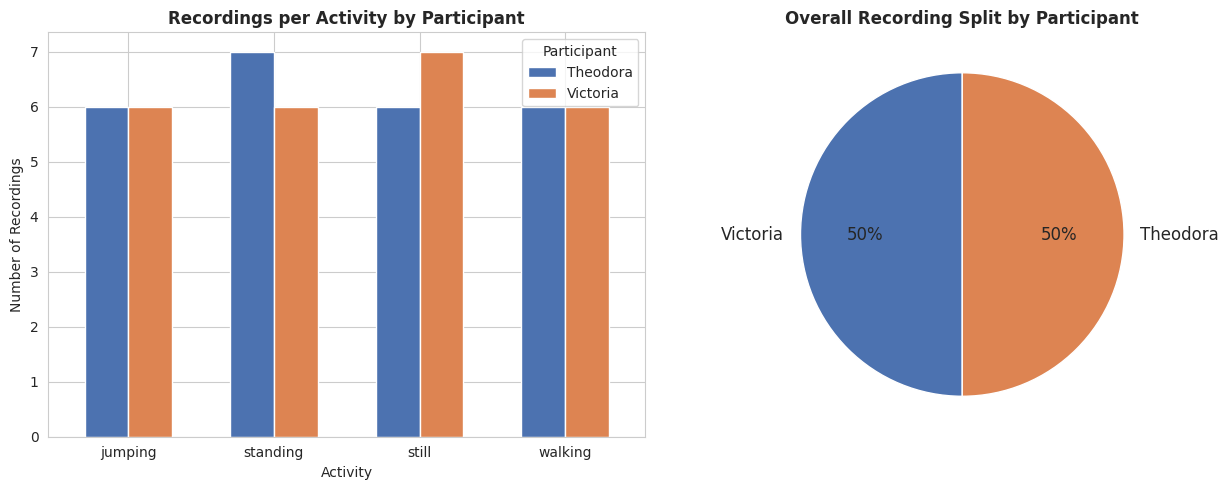

activity     jumping  standing  still  walking
participant                                   
Theodora           6         7      6        6
Victoria           6         6      7        6


In [12]:
# Participant contribution breakdown
part_df = pd.DataFrame({"participant": all_participants, "activity": all_activities})
pivot = part_df.groupby(["participant", "activity"]).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grouped bar chart
pivot.T.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.6)
axes[0].set_title("Recordings per Activity by Participant", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Activity")
axes[0].set_ylabel("Number of Recordings")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Participant")

# Overall contribution pie
total_per_part = part_df["participant"].value_counts()
axes[1].pie(total_per_part.values, labels=total_per_part.index, autopct="%1.0f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90, textprops={"fontsize": 12})
axes[1].set_title("Overall Recording Split by Participant", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("participant_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(pivot)

## 3. Feature Extraction

From each time window, compute **time-domain** and **frequency-domain** features to form the observation sequence for the HMM.

**Time-domain:** mean, variance, std, SMA (signal magnitude area), correlation between axes  
**Frequency-domain:** dominant frequency, spectral energy, FFT components

In [13]:
WINDOW_SIZE = 50   # samples per window (~0.5s at 100Hz)
WINDOW_STEP = 25   # overlap 50%

def extract_features(window: np.ndarray) -> np.ndarray:
    """Extract 7 features: RMS, Std, SMA, ZCR, Dominant Freq, Spectral Energy, Spectral Entropy."""
    acc = window[:, :3]
    acc_mag = np.sqrt(np.sum(acc**2, axis=1))
    n = len(acc_mag)
    # 1. RMS - motion intensity
    rms = np.sqrt(np.mean(acc_mag**2))
    # 2. Standard Deviation - signal variability
    std = np.std(acc_mag)
    # 3. SMA - total movement magnitude
    sma = np.mean(np.abs(acc[:, 0]) + np.abs(acc[:, 1]) + np.abs(acc[:, 2]))
    # 4. Zero Crossing Rate - oscillation rate
    acc_centered = acc_mag - np.mean(acc_mag)
    zero_crossings = np.sum(np.abs(np.diff(np.sign(acc_centered)))) / 2
    zcr = zero_crossings / (n - 1) if n > 1 else 0.0
    # 5-7. Frequency-domain (FFT)
    fft_vals = np.abs(fft(acc_mag))[:n//2]
    freqs = fftfreq(n, 1/100)[:n//2]
    dominant_freq = freqs[np.argmax(fft_vals)] if len(fft_vals) > 0 else 0.0
    spectral_energy = np.sum(fft_vals**2) / len(fft_vals) if len(fft_vals) > 0 else 0.0
    psd = fft_vals**2
    psd_norm = psd / (np.sum(psd) + 1e-10)
    spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-10)) if len(psd_norm) > 0 else 0.0
    return np.array([rms, std, sma, zcr, dominant_freq, spectral_energy, spectral_entropy], dtype=np.float32)

def sequence_to_features(seq: np.ndarray) -> np.ndarray:
    """Convert raw sequence to feature matrix (num_windows, 7)."""
    n = len(seq)
    windows = []
    for start in range(0, n - WINDOW_SIZE + 1, WINDOW_STEP):
        w = seq[start:start + WINDOW_SIZE]
        windows.append(extract_features(w))
    return np.array(windows) if windows else np.array([]).reshape(0, 7)

In [14]:
# Extract features from all sequences
X_list = []
y_list = []
lengths = []

for seq, act in zip(all_sequences, all_activities):
    X = sequence_to_features(seq)
    if len(X) == 0:
        continue
    X_list.append(X)
    y_list.extend([act] * len(X))
    lengths.append(len(X))

X_train = np.vstack(X_list)
y_train_labels = np.array(y_list)
lengths = np.array(lengths)
print(f"Feature matrix shape: {X_train.shape}")
print(f"Sequence lengths: {lengths[:10]}... (total {len(lengths)} sequences)")

Feature matrix shape: (1620, 7)
Sequence lengths: [37 31 34 32 34 31 32 30 30 33]... (total 50 sequences)


In [15]:
# Handle NaN/Inf in features
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Encode labels for evaluation
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_labels)
print("Activity classes:", le.classes_)

Activity classes: ['jumping' 'standing' 'still' 'walking']



### Windowing Logic (Based on Sampling Rate)
- **Sampling rate:** 100 Hz (10 ms interval), harmonized across devices
- **Window size:** 50 samples ≈ 0.5 seconds
- **Rationale:** At 100 Hz, 50 samples capture ~0.5 seconds of motion—enough for at least one stride (walking ~1–2 Hz) or one jump cycle (~0.5–1 Hz), while short enough to track activity transitions. Shorter windows add noise; longer windows blur transitions.
- **Step size:** 25 samples (50% overlap) for smoother transitions and more observations for the HMM.

### Handling Different Sampling Rates
- Recordings target 100 Hz (10 ms) via Sensor Logger.
- **Resampling:** Time alignment uses `merge_asof` with 15 ms tolerance, then interpolation onto a 10 ms grid.
- **Effect:** All trials are brought to 100 Hz before feature extraction, so window sizes and features are comparable across participants and sessions.

---

## Feature Extraction: Relevance & Justification

### Time-Domain Features (>2)

| Feature | Formula | Why It Helps Distinguish Activities |
|---------|---------|-------------------------------------|
| **RMS** | √(mean(acc_mag²)) | Motion intensity. Still ≈ 1g; jumping highest. Separates low vs high motion. |
| **Standard Deviation** | σ(acc_mag) | Variability. Still ≈ 0; walking/jumping higher. Separates static vs dynamic. |
| **SMA** | mean(\|acc_x\|+\|acc_y\|+\|acc_z\|) | Total movement magnitude. Still minimal; jumping largest. Separates still vs jumping. |
| **Zero Crossing Rate** | Rate of sign changes in centered signal | Oscillation rate. Still low; walking higher (cyclic). Separates rhythmic vs non-rhythmic. |

### Frequency-Domain Features (>1, from FFT)

| Feature | Formula | Why It Helps Distinguish Activities |
|---------|---------|-------------------------------------|
| **Dominant Frequency** | Frequency at max FFT magnitude | Walking ~1–2 Hz; jumping ~0.5–1 Hz; still near 0. Separates rhythmic vs non-rhythmic. |
| **Spectral Energy** | Σ\|FFT\|² (normalized) | Total energy in spectrum. Still low; jumping high. Complements time-domain energy. |
| **Spectral Entropy** | -Σ p_k log(p_k) on normalized PSD | Spectrum complexity. Still/standing more peaked; walking/jumping more spread. Separates simple vs complex motion. |

### Normalization: Z-Score (StandardScaler)
- **Method:** Each feature standardized to mean 0, std 1.
- **Reason:** Features have different units (g, Hz, etc.). Z-score puts them on a common scale so no single feature dominates the HMM.
- **Effect:** Improves Baum–Welch convergence and makes emission distributions comparable.



## 4. Define HMM Model Components

Before training, we formally define the structure of our Hidden Markov Model based on the collected data.

---

### Hidden States (Z)

The hidden states represent the **true underlying activity** the model cannot observe directly, only sensor readings are observable.

| State Index | Activity | Description |
|---|---|---|
| 0 | **Still** | Phone placed flat, no movement |
| 1 | **Standing** | Upright, phone at waist, minimal motion |
| 2 | **Walking** | Consistent forward movement at normal pace |
| 3 | **Jumping** | Continuous repetitive jumps |

---

### Observations (X)

Observations are the **7-dimensional feature vectors** extracted from each 0.5-second sliding window:

X = [RMS, Std, SMA, ZCR, Dominant Frequency, Spectral Energy, Spectral Entropy]

Each observation is a snapshot of what the sensors measured during one window. The HMM learns which feature patterns correspond to which hidden state.

---

### Transition Probabilities (A)

The 4x4 transition matrix **A** defines the probability of moving from one activity state to another between consecutive windows:

A_ij = P(Z_{t+1} = j | Z_t = i)

We expect **high self-transition probabilities** on the diagonal — if currently walking, the model is likely still walking in the next window. Off-diagonal values represent activity switches, which are rare.

- Initialized as **uniform**, then refined by Baum-Welch.

---

### Emission Probabilities (B)

Since observations are **continuous feature vectors**, emissions are modelled as **multivariate Gaussian distributions** — one per hidden state:

B_i(X_t) = N(X_t | mu_i, Sigma_i)

Each state has its own mean vector and covariance matrix, learned during Baum-Welch. We use **diagonal covariance** to reduce parameters and avoid overfitting on our small dataset.

---

### Initial State Probabilities (pi)

The vector pi defines the likelihood of **starting in each state** at the beginning of a sequence:

pi_i = P(Z_1 = i)

Initialized as **uniform** (equal probability for all 4 states) since recordings can start from any activity. Baum-Welch refines this during training.

---

### Summary Table

| Component | Symbol | Type | Value / Method |
|---|---|---|---|
| Hidden States | Z | Discrete | 4 states: still, standing, walking, jumping |
| Observations | X | Continuous | 7-feature vector per 0.5s window |
| Transition Matrix | A | 4x4 matrix | Initialized uniform, learned via Baum-Welch |
| Emission Probs | B | Gaussian | Diagonal covariance, learned via Baum-Welch |
| Initial Probs | pi | 4-vector | Initialized uniform, learned via Baum-Welch |


In [16]:
# ── HMM Model Component Definitions ──

ACTIVITIES = ["still", "standing", "walking", "jumping"]
N_STATES   = len(ACTIVITIES)
N_FEATURES = 7

# Hidden States (Z)
print("=" * 50)
print("HIDDEN STATES (Z)")
print("=" * 50)
for i, act in enumerate(ACTIVITIES):
    print(f"  State {i}: {act}")

# Observations (X)
print("\n" + "=" * 50)
print("OBSERVATIONS (X)")
print("=" * 50)
feature_names = ["RMS", "Std Dev", "SMA", "Zero Crossing Rate",
                  "Dominant Frequency", "Spectral Energy", "Spectral Entropy"]
for i, f in enumerate(feature_names):
    print(f"  Feature {i+1}: {f}")
print(f"  Observation shape per window: ({N_FEATURES},)")

# Transition Matrix A — uniform initialization
print("\n" + "=" * 50)
print("TRANSITION MATRIX (A) — initial uniform")
print("=" * 50)
A_init = np.full((N_STATES, N_STATES), 1.0 / N_STATES)
print(pd.DataFrame(A_init, index=ACTIVITIES, columns=ACTIVITIES).round(3))

# Initial State Probabilities pi — uniform
print("\n" + "=" * 50)
print("INITIAL STATE PROBABILITIES (pi) — uniform")
print("=" * 50)
pi_init = np.full(N_STATES, 1.0 / N_STATES)
for act, p in zip(ACTIVITIES, pi_init):
    print(f"  P(start={act}) = {p:.3f}")

# Emission Probabilities B — Gaussian, learned during training
print("\n" + "=" * 50)
print("EMISSION PROBABILITIES (B)")
print("=" * 50)
print("  Type    : Multivariate Gaussian per hidden state")
print("  Cov type: Diagonal (features treated as independent)")
print("  Params  : mean vector (7,) + variance vector (7,) per state")
print("  Learned : Baum-Welch (Expectation-Maximization)")

print(f"\nModel summary: {N_STATES} hidden states x {N_FEATURES} features")


HIDDEN STATES (Z)
  State 0: still
  State 1: standing
  State 2: walking
  State 3: jumping

OBSERVATIONS (X)
  Feature 1: RMS
  Feature 2: Std Dev
  Feature 3: SMA
  Feature 4: Zero Crossing Rate
  Feature 5: Dominant Frequency
  Feature 6: Spectral Energy
  Feature 7: Spectral Entropy
  Observation shape per window: (7,)

TRANSITION MATRIX (A) — initial uniform
          still  standing  walking  jumping
still      0.25      0.25     0.25     0.25
standing   0.25      0.25     0.25     0.25
walking    0.25      0.25     0.25     0.25
jumping    0.25      0.25     0.25     0.25

INITIAL STATE PROBABILITIES (pi) — uniform
  P(start=still) = 0.250
  P(start=standing) = 0.250
  P(start=walking) = 0.250
  P(start=jumping) = 0.250

EMISSION PROBABILITIES (B)
  Type    : Multivariate Gaussian per hidden state
  Cov type: Diagonal (features treated as independent)
  Params  : mean vector (7,) + variance vector (7,) per state
  Learned : Baum-Welch (Expectation-Maximization)

Model summary: 